In [5]:
!unzip -q BoneHealthDataset.zip -d dataset_ossos

In [6]:
import tensorflow as tf

diretorio_dados = 'dataset_ossos'
tamanho_lote = 32
altura_img = 224
largura_img = 224

train_ds = tf.keras.utils.image_dataset_from_directory(
  diretorio_dados,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(altura_img, largura_img),
  batch_size=tamanho_lote)

val_ds = tf.keras.utils.image_dataset_from_directory(
  diretorio_dados,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(altura_img, largura_img),
  batch_size=tamanho_lote)

Found 1947 files belonging to 3 classes.
Using 1558 files for training.
Found 1947 files belonging to 3 classes.
Using 389 files for validation.


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

# Otimização de leitura para o treino ser mais rápido
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Camadas de Data Augmentation
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.1),
  tf.keras.layers.RandomZoom(0.1),
])

In [8]:
# Carregando o modelo base pré-treinado
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(altura_img, largura_img, 3),
    include_top=False,
    weights='imagenet'
)

# Congelando os pesos pré-existentes
base_model.trainable = False

# Construindo a nova arquitetura
inputs = tf.keras.Input(shape=(altura_img, largura_img, 3))
x = data_augmentation(inputs) # Aplica o aumento de dados configurado no passo anterior
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x) # Dropout para reduzir overfitting
outputs = tf.keras.layers.Dense(3, activation='softmax')(x) # 3 saídas (Normal, Osteopenia, Osteoporosis)

modelo = tf.keras.Model(inputs, outputs)

# Compilando o modelo
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Exibindo o resumo da arquitetura
modelo.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [12]:
epocas = 15

# Iniciando o treinamento
historico = modelo.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epocas
)

Epoch 1/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 230s 4s/step - accuracy: 0.5661 - loss: 0.8795 - val_accuracy: 0.6401 - val_loss: 0.7316
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step - accuracy: 0.6656 - loss: 0.7319 - val_accuracy: 0.7044 - val_loss: 0.6562
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step - accuracy: 0.6926 - loss: 0.6859 - val_accuracy: 0.7404 - val_loss: 0.6200
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.7028 - loss: 0.6552 - val_accuracy: 0.7429 - val_loss: 0.6021
Epoch 5/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 169s 3s/step - accuracy: 0.7157 - loss: 0.6369 - val_accuracy: 0.7584 - val_loss: 0.5930
Epoch 6/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - accuracy: 0.7022 - loss: 0.6459 - val_accuracy: 0.7481 - val_loss: 0.6016
Epoch 7/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step - accuracy: 0.7144 - loss: 0.6256 - val_accuracy: 0.7635 - val_loss: 0.5790
Epoch 8/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 169s 3s/step - accuracy: 0.7195 - loss: 0.6167 - val_accuracy: 0.7661 - v

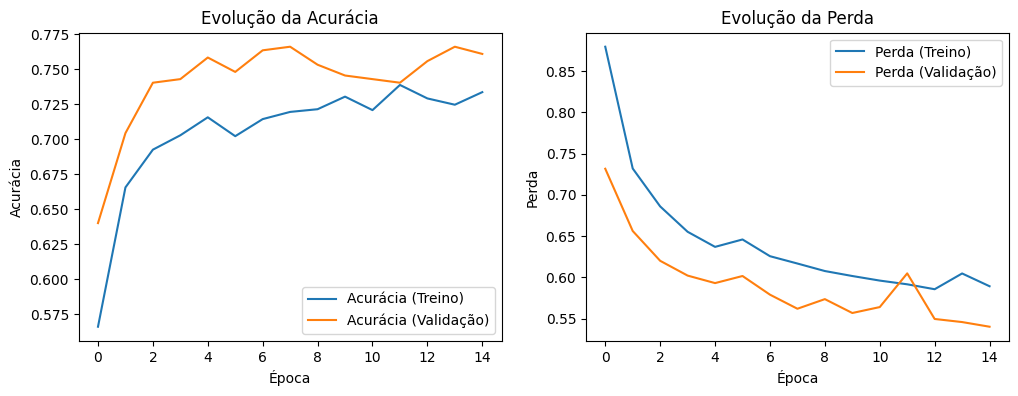

Modelo salvo com sucesso como 'boneguard_modelo.h5'


In [13]:
import matplotlib.pyplot as plt

# Criando os gráficos de Acurácia e Perda
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historico.history['accuracy'], label='Acurácia (Treino)')
plt.plot(historico.history['val_accuracy'], label='Acurácia (Validação)')
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historico.history['loss'], label='Perda (Treino)')
plt.plot(historico.history['val_loss'], label='Perda (Validação)')
plt.title('Evolução da Perda')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()

plt.show()

# Salvando o modelo treinado
modelo.save('boneguard_modelo.h5')
print("Modelo salvo com sucesso como 'boneguard_modelo.h5'")

--- Relatório de Classificação ---
              precision    recall  f1-score   support

      Normal       0.92      0.69      0.79       160
  Osteopenia       0.70      0.79      0.74        73
Osteoporosis       0.69      0.81      0.74       156

    accuracy                           0.76       389
   macro avg       0.77      0.77      0.76       389
weighted avg       0.78      0.76      0.76       389



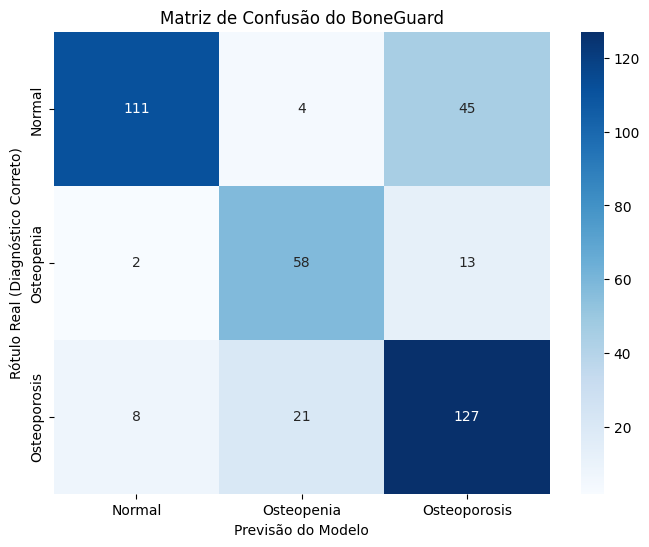

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os # Import os module to list directories

# Extraindo rótulos reais e previsões do conjunto de validação
y_true = []
y_pred = []

for imagens, rotulos in val_ds:
    previsoes = modelo.predict(imagens, verbose=0)
    y_true.extend(rotulos.numpy())
    y_pred.extend(np.argmax(previsoes, axis=1))

# Get class names from directory structure, as image_dataset_from_directory does
# 'diretorio_dados' is defined in cell 8B8LtJpDLET0
nomes_classes = sorted(os.listdir(diretorio_dados))

# Imprimindo o Relatório de Classificação
print("--- Relatório de Classificação ---")
print(classification_report(y_true, y_pred, target_names=nomes_classes))

# Gerando o gráfico da Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title('Matriz de Confusão do BoneGuard')
plt.ylabel('Rótulo Real (Diagnóstico Correto)')
plt.xlabel('Previsão do Modelo')
plt.show()

In [9]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# 1. Calculando os pesos automaticamente com base no dataset de treino
y_train = np.concatenate([y for x, y in train_ds], axis=0)
pesos = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
pesos_classes = dict(enumerate(pesos))
print("Pesos das classes:", pesos_classes)

# 2. Fine-Tuning: Descongelando as últimas camadas do modelo base
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False  # Mantém as primeiras 100 congeladas

# Recompilando com uma taxa de aprendizado bem menor para não destruir os pesos
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# 3. Callbacks para salvar tempo e otimizar a rede
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)
]

# 4. Treinamento
print("\nIniciando Fine-Tuning...")
historico_finetuning = modelo.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=pesos_classes,
    callbacks=callbacks
)

# Salvando o novo modelo
modelo.save('boneguard_modelo_v2.h5')
print("\nNovo modelo salvo como 'boneguard_modelo_v2.h5'")

Pesos das classes: {0: np.float64(0.8376344086021505), 1: np.float64(1.725359911406423), 2: np.float64(0.815279958137101)}

Iniciando Fine-Tuning...
Epoch 1/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 164s 3s/step - accuracy: 0.5899 - loss: 0.8141 - val_accuracy: 0.6684 - val_loss: 0.8258 - learning_rate: 1.0000e-04
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.7343 - loss: 0.5822 - val_accuracy: 0.7352 - val_loss: 0.6224 - learning_rate: 1.0000e-04
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.7535 - loss: 0.5336 - val_accuracy: 0.7609 - val_loss: 0.5437 - learning_rate: 1.0000e-04
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.7670 - loss: 0.4913 - val_accuracy: 0.7404 - val_loss: 0.5502 - learning_rate: 1.0000e-04
Epoch 5/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.7888 - loss: 0.4501 - val_accuracy: 0.7455 - val_loss: 0.5553 - learning_rate: 1.0000e-04
Epoch 6/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.8113 - loss


Novo modelo salvo como 'boneguard_modelo_v2.h5'


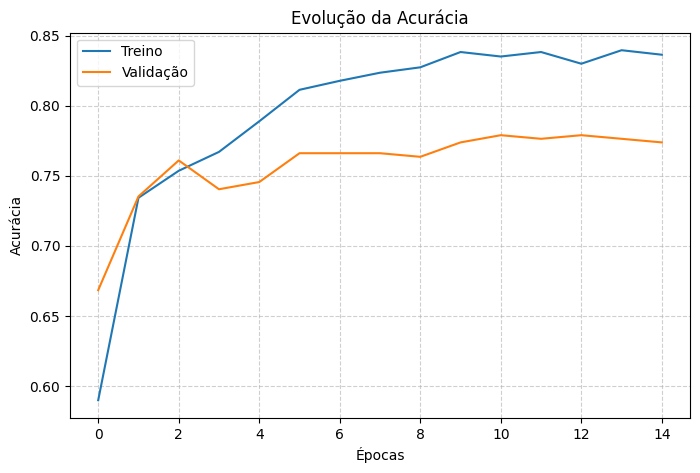

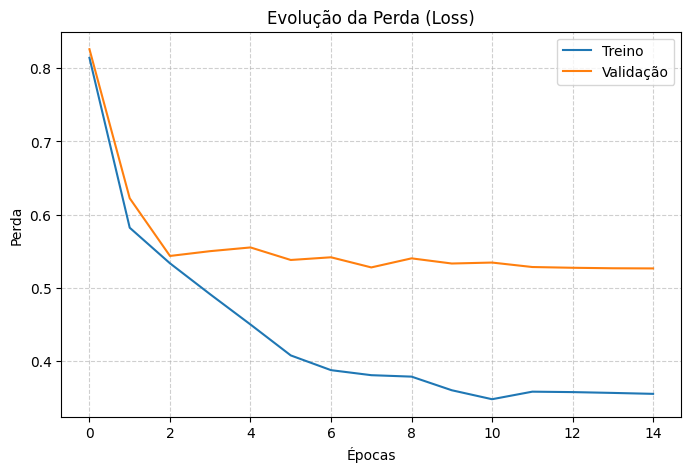

In [10]:
import matplotlib.pyplot as plt

# Gráfico de Acurácia
plt.figure(figsize=(8, 5))
plt.plot(historico_finetuning.history['accuracy'], label='Treino')
plt.plot(historico_finetuning.history['val_accuracy'], label='Validação')
plt.title('Evolução da Acurácia')
plt.ylabel('Acurácia')
plt.xlabel('Épocas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('grafico_acuracia.png', bbox_inches='tight')
plt.show()

# Gráfico de Perda (Loss)
plt.figure(figsize=(8, 5))
plt.plot(historico_finetuning.history['loss'], label='Treino')
plt.plot(historico_finetuning.history['val_loss'], label='Validação')
plt.title('Evolução da Perda (Loss)')
plt.ylabel('Perda')
plt.xlabel('Épocas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('grafico_perda.png', bbox_inches='tight')
plt.show()

Gerando previsões para a Matriz de Confusão. Aguarde...


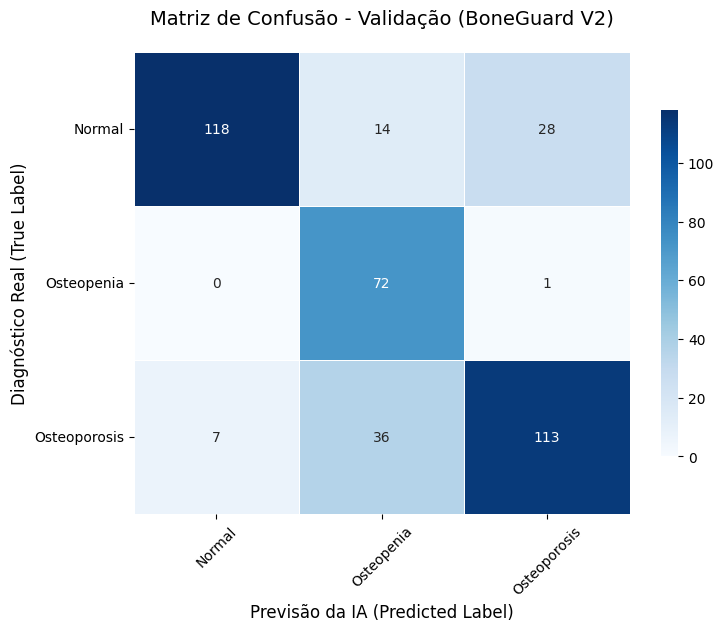


Matriz salva como 'grafico_matriz_confusao.png'


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Gerando previsões para a Matriz de Confusão. Aguarde...")

y_true = []
y_pred = []

# Extrai os rótulos reais e faz as previsões usando o dataset de validação
for images, labels in val_ds:
    y_true.extend(labels.numpy())
    previsoes_batch = modelo.predict(images, verbose=0)
    y_pred.extend(np.argmax(previsoes_batch, axis=1))

# Calcula a matriz
cm = confusion_matrix(y_true, y_pred)

# Nomes das classes (certifique-se de que estão na mesma ordem do treinamento)
nomes_classes = ['Normal', 'Osteopenia', 'Osteoporosis']

# Plotagem do gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_classes,
            yticklabels=nomes_classes,
            linewidths=.5,
            cbar_kws={"shrink": .75})

plt.title('Matriz de Confusão - Validação (BoneGuard V2)', pad=20, fontsize=14)
plt.ylabel('Diagnóstico Real (True Label)', fontsize=12)
plt.xlabel('Previsão da IA (Predicted Label)', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Salva a imagem para você baixar
plt.savefig('grafico_matriz_confusao.png', bbox_inches='tight', dpi=300)
plt.show()

print("\nMatriz salva como 'grafico_matriz_confusao.png'")